In [26]:
import numpy as np
import pandas as pd
from Bio.Align import substitution_matrices

In [27]:
df = pd.read_csv("../data/features_pssm/virus_cleavage_11mer_dataset.csv")

print(df.shape)
df.head()

(72679, 4)


,protein_id,position,window,label
0,UniProt:P59594,257,FVGYLKPTTFM,1
1,NCBI:P59641.2,3606,AMLLVKHKHAF,1
2,NCBI:P15059.2,303,ATCALVSDCAS,1
3,NCBI:AAL01351.1,88,SEYRHYCYSLY,1
4,UniProt:A0A087VSD2,800,TGLWSLALLVL,1


In [28]:
blosum62 = substitution_matrices.load("BLOSUM62")

aa_list = list("ARNDCQEGHILKMFPSTWYV")

In [29]:
def pssm_encode(seq):

    features = []

    for aa in seq:
        row = [blosum62[aa, ref] for ref in aa_list]
        features.extend(row)

    return features

In [30]:
sequences = df["window"].values

In [31]:
sequences[:5]

<StringArray>
['FVGYLKPTTFM', 'AMLLVKHKHAF', 'ATCALVSDCAS', 'SEYRHYCYSLY', 'TGLWSLALLVL']
Length: 5, dtype: str

In [32]:
X_pssm = np.array([pssm_encode(seq) for seq in sequences], dtype=np.float32)

print(X_pssm.shape)

(72679, 220)


In [33]:
np.save("../data/features_pssm/X_pssm.npy", X_pssm)

In [34]:
X_pssm = np.load("../data/features_pssm/X_pssm.npy")

In [35]:
y = df["label"].values

In [36]:
train_df = pd.read_csv("../data/features_pssm/train_dataset.csv")
test_df  = pd.read_csv("../data/features_pssm/test_dataset.csv")

In [37]:
X_train_pssm = X_pssm[train_df.index]
X_test_pssm  = X_pssm[test_df.index]

y_train = train_df["label"].values
y_test  = test_df["label"].values

In [45]:
np.save("../data/features_pssm/X_train_pssm.npy", X_train_pssm)
np.save("../data/features_pssm/X_test_pssm.npy", X_test_pssm)

np.save("../data/features_pssm/y_train.npy", y_train)
np.save("../data/features_pssm/y_test.npy", y_test)

In [46]:
X_train_pssm = np.load("../data/features_pssm/X_train_pssm.npy")
X_test_pssm  = np.load("../data/features_pssm/X_test_pssm.npy")

y_train = np.load("../data/features_pssm/y_train.npy")
y_test  = np.load("../data/features_pssm/y_test.npy")

In [49]:
print("Train:", train_df.shape)
print("Test:", test_df.shape)

Train: (55292, 4)
Test: (17387, 4)


In [50]:
print(X_train_pssm.shape)
print(X_test_pssm.shape)

(55292,)
(17387,)


In [ ]:
np.save("../data/features_pssm/X_train_pssm.npy", X_train_pssm)
np.save("../data/features_pssm/X_test_pssm.npy", X_test_pssm)

np.save("../data/features_pssm/y_train.npy", y_train)
np.save("../data/features_pssm/y_test.npy", y_test)

In [51]:
X_train_pssm = np.load("../data/features_pssm/X_train_pssm.npy")
X_test_pssm  = np.load("../data/features_pssm/X_test_pssm.npy")

y_train = np.load("../data/features_pssm/y_train.npy")
y_test  = np.load("../data/features_pssm/y_test.npy")

In [52]:
from sklearn.ensemble import RandomForestClassifier
 
rf_pssm = RandomForestClassifier( max_depth=40, max_features="sqrt", min_samples_leaf=2, min_samples_split=5, n_estimators=500, class_weight="balanced_subsample", n_jobs=-1, random_state=42 ) 
  
rf_pssm.fit(X_train_pssm, y_train)

ValueError: Expected 2D array, got 1D array instead:
array=[1. 1. 1. ... 0. 0. 0.].
Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.

Train ROC-AUC: 0.9998087892496182
Test ROC-AUC : 0.8126145292748032


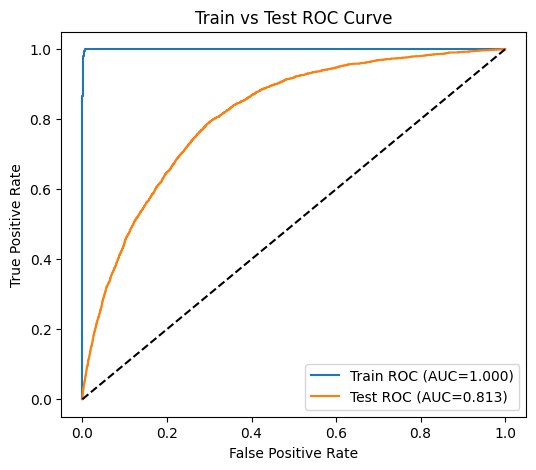

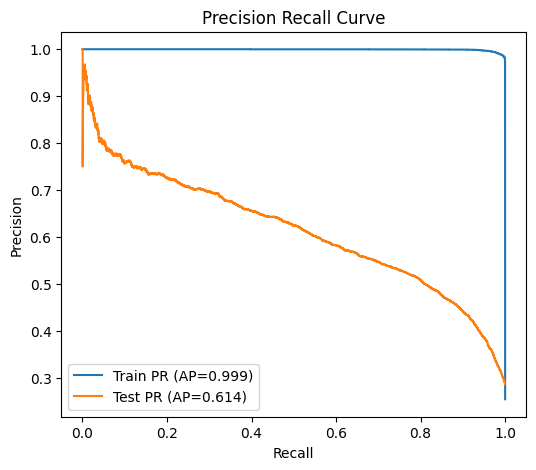

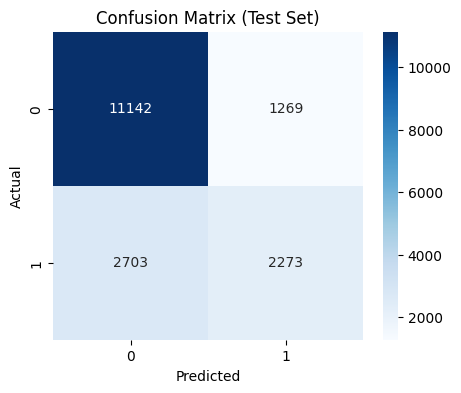


Classification Report (Test Set)

              precision    recall  f1-score   support

           0       0.80      0.90      0.85     12411
           1       0.64      0.46      0.53      4976

    accuracy                           0.77     17387
   macro avg       0.72      0.68      0.69     17387
weighted avg       0.76      0.77      0.76     17387

      Metric     Score
0   Accuracy  0.771553
1  Precision  0.641728
2     Recall  0.456793
3   F1-score  0.533693
4    ROC-AUC  0.812615


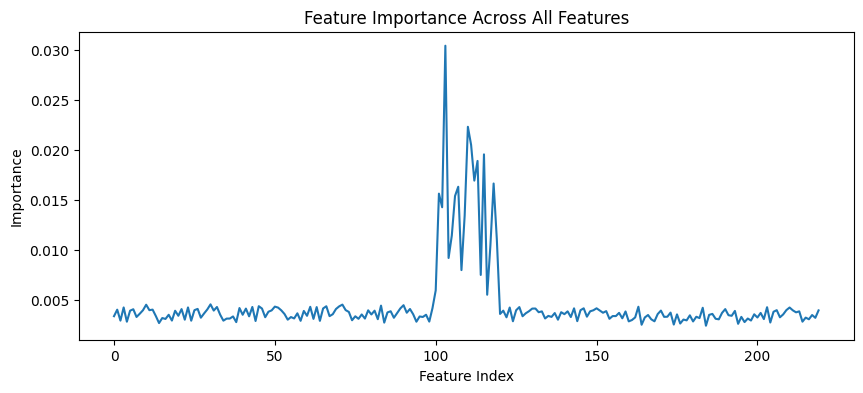

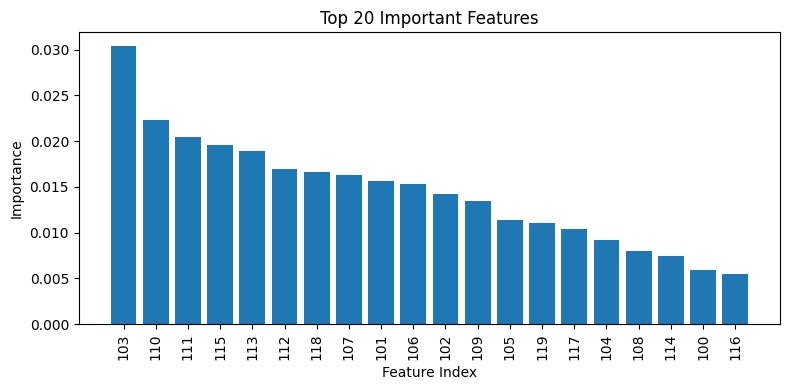


All plots saved in ../results/


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# --------------------------------------------------
# Create results directory
# --------------------------------------------------

os.makedirs("../data/features_pssm/results", exist_ok=True)

# --------------------------------------------------
# Predictions
# --------------------------------------------------

train_probs = rf_pssm.predict_proba(X_train_pssm)[:,1]
test_probs  = rf_pssm.predict_proba(X_test_pssm)[:,1]

train_pred = rf_pssm.predict(X_train_pssm)
test_pred  = rf_pssm.predict(X_test_pssm)

# --------------------------------------------------
# ROC AUC
# --------------------------------------------------

train_auc = roc_auc_score(y_train, train_probs)
test_auc  = roc_auc_score(y_test, test_probs)

print("Train ROC-AUC:", train_auc)
print("Test ROC-AUC :", test_auc)

# --------------------------------------------------
# ROC Curve
# --------------------------------------------------

fpr_train, tpr_train, _ = roc_curve(y_train, train_probs)
fpr_test, tpr_test, _ = roc_curve(y_test, test_probs)

plt.figure(figsize=(6,5))

plt.plot(fpr_train, tpr_train, label=f"Train ROC (AUC={train_auc:.3f})")
plt.plot(fpr_test, tpr_test, label=f"Test ROC (AUC={test_auc:.3f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Train vs Test ROC Curve")
plt.legend()

plt.savefig("../results/roc_curve.png", dpi=300)
plt.show()

# --------------------------------------------------
# Precision Recall Curve
# --------------------------------------------------

precision_train, recall_train, _ = precision_recall_curve(y_train, train_probs)
precision_test, recall_test, _ = precision_recall_curve(y_test, test_probs)

ap_train = average_precision_score(y_train, train_probs)
ap_test  = average_precision_score(y_test, test_probs)

plt.figure(figsize=(6,5))

plt.plot(recall_train, precision_train, label=f"Train PR (AP={ap_train:.3f})")
plt.plot(recall_test, precision_test, label=f"Test PR (AP={ap_test:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision Recall Curve")
plt.legend()

plt.savefig("../results/pr_curve.png", dpi=300)
plt.show()

# --------------------------------------------------
# Confusion Matrix (TEST ONLY)
# --------------------------------------------------

cm = confusion_matrix(y_test, test_pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Test Set)")

plt.savefig("../results/confusion_matrix.png", dpi=300)
plt.show()

# --------------------------------------------------
# Classification Metrics
# --------------------------------------------------

print("\nClassification Report (Test Set)\n")

print(classification_report(y_test, test_pred))

acc = accuracy_score(y_test, test_pred)
prec = precision_score(y_test, test_pred)
rec = recall_score(y_test, test_pred)
f1 = f1_score(y_test, test_pred)

metrics_df = pd.DataFrame({
    "Metric": ["Accuracy","Precision","Recall","F1-score","ROC-AUC"],
    "Score": [acc,prec,rec,f1,test_auc]
})

print(metrics_df)

metrics_df.to_csv("../results/model_metrics.csv",index=False)

# --------------------------------------------------
# Feature Importance
# --------------------------------------------------

importances = rf_pssm.feature_importances_

plt.figure(figsize=(10,4))
plt.plot(importances)

plt.xlabel("Feature Index")
plt.ylabel("Importance")
plt.title("Feature Importance Across All Features")

plt.savefig("../results/feature_importance.png", dpi=300)
plt.show()

# --------------------------------------------------
# Top 20 Features
# --------------------------------------------------

indices = np.argsort(importances)[::-1][:20]

plt.figure(figsize=(8,4))

plt.bar(range(20), importances[indices])

plt.xticks(range(20), indices, rotation=90)

plt.xlabel("Feature Index")
plt.ylabel("Importance")
plt.title("Top 20 Important Features")

plt.tight_layout()

plt.savefig("../results/top20_features.png", dpi=300)
plt.show()

print("\nAll plots saved in ../results/")